In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np

In [9]:
fire_grid_fp = 'data_preprocess/fire_event_shp_modis_af/attributes/mapbiomas_c4_ver/v4_500m_60cl/8_grids_ros/sumatra/fire_2015_id_15860_grid.shp'

In [10]:
fire_grid = gpd.read_file(fire_grid_fp)

In [15]:
fire_point_fp = 'data_preprocess/fire_event_shp_modis_af/attributes/mapbiomas_c4_ver/v4_500m_60cl/1_fire_character/sumatra/fire_2015_id_15860.shp'

In [16]:
fire_point = gpd.read_file(fire_point_fp)

In [17]:
fire_point

,index_af,LATITUDE,LONGITUDE,BRIGHTNESS,ACQ_DATE,ACQ_TIME,CONFIDENCE,BRIGHT_T31,FRP,index_righ,...,dist_point,days_diff_,dist_event,cumm_days,fire_durat,ros_avg_cu,ros_avg_du,step1_id,step2_id,geometry
0,152991,-3.3490,103.5641,352.0,2015-09-13,0630,96,305.3,82.0,6115796,...,1106.339196,1,3698.186974,2,3,1849.093487,1232.728991,152950,152991,POINT (-383306.83 -355824.963)
1,152981,-3.3529,103.5581,350.1,2015-09-11,0348,95,302.0,84.6,6118498,...,0.000000,0,3698.186974,0,3,0.000000,1232.728991,152981,152981,POINT (-383972.828 -356256.782)
2,152959,-3.3534,103.5597,361.7,2015-09-13,0336,100,309.2,80.8,6118499,...,1174.558102,1,3698.186974,2,3,1849.093487,1232.728991,152950,152959,POINT (-383795.204 -356312.105)
3,152952,-3.3567,103.5640,334.3,2015-09-11,0348,86,300.4,40.6,6121204,...,0.000000,0,3698.186974,0,3,0.000000,1232.728991,152952,152952,POINT (-383317.807 -356677.337)
4,152957,-3.3547,103.5686,381.1,2015-09-13,0336,100,309.9,148.2,6121205,...,315.139394,1,3698.186974,2,3,1849.093487,1232.728991,152950,152957,POINT (-382807.193 -356455.868)
5,152950,-3.3574,103.5695,311.4,2015-09-12,1512,82,293.6,26.6,6121205,...,615.452959,1,3698.186974,1,3,3698.186974,1232.728991,152952,152950,POINT (-382707.241 -356754.737)
6,152924,-3.3592,103.5655,337.8,2015-09-13,0630,88,305.7,42.0,6123908,...,486.697323,1,3698.186974,2,3,1849.093487,1232.728991,152950,152924,POINT (-383151.252 -356954.056)


In [20]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar 

In [23]:
fire_grid

,grid_id,lon,lat,fire_id,year,af_count,area_km2,buffer_m,date_min,date_max,...,tp_hourly,ev_h,pev_hourly,conv_preci,conv_rain_,sp_pa,mslp_pa,burn_durat,ros_km2_da,geometry
0,6115795,103.560417,-3.347917,15860,2015,7,1.784398,250,2015-09-11,2015-09-13,...,0.0,-0.000019,-0.000044,0.0,0.0,100479.8125,101283.5625,3,1.333333,"POLYGON ((-383484.498 -355474.444, -383484.431..."
1,6115796,103.564583,-3.347917,15860,2015,7,1.784398,250,2015-09-11,2015-09-13,...,0.0,-0.000019,-0.000044,0.0,0.0,100479.8125,101283.5625,3,1.333333,"POLYGON ((-383021.956 -355474.377, -383021.889..."
2,6115797,103.568750,-3.347917,15860,2015,7,1.784398,250,2015-09-11,2015-09-13,...,0.0,-0.000019,-0.000044,0.0,0.0,100479.8125,101283.5625,3,1.333333,"POLYGON ((-382559.413 -355474.31, -382559.347 ..."
3,6118498,103.556250,-3.352083,15860,2015,7,1.784398,250,2015-09-11,2015-09-13,...,0.0,-0.000014,-0.000044,0.0,0.0,100504.7500,101307.8750,3,1.333333,"POLYGON ((-383946.973 -355935.754, -383946.906..."
4,6118499,103.560417,-3.352083,15860,2015,7,1.784398,250,2015-09-11,2015-09-13,...,0.0,-0.000019,-0.000044,0.0,0.0,100479.8125,101283.5625,3,1.333333,"POLYGON ((-383484.431 -355935.687, -383484.364..."
5,6118500,103.564583,-3.352083,15860,2015,7,1.784398,250,2015-09-11,2015-09-13,...,0.0,-0.000019,-0.000044,0.0,0.0,100479.8125,101283.5625,3,1.333333,"POLYGON ((-383021.889 -355935.62, -383021.822 ..."
6,6118501,103.568750,-3.352083,15860,2015,7,1.784398,250,2015-09-11,2015-09-13,...,0.0,-0.000019,-0.000044,0.0,0.0,100479.8125,101283.5625,3,1.333333,"POLYGON ((-382559.347 -355935.553, -382559.28 ..."
7,6121202,103.556250,-3.356250,15860,2015,7,1.784398,250,2015-09-11,2015-09-13,...,0.0,-0.000014,-0.000044,0.0,0.0,100504.7500,101307.8750,3,1.333333,"POLYGON ((-383946.906 -356396.995, -383946.839..."
8,6121203,103.560417,-3.356250,15860,2015,7,1.784398,250,2015-09-11,2015-09-13,...,0.0,-0.000019,-0.000044,0.0,0.0,100479.8125,101283.5625,3,1.333333,"POLYGON ((-383484.364 -356396.928, -383484.297..."
9,6121204,103.564583,-3.356250,15860,2015,7,1.784398,250,2015-09-11,2015-09-13,...,0.0,-0.000014,-0.000044,0.0,0.0,100504.7500,101307.8750,3,1.333333,"POLYGON ((-383021.822 -356396.861, -383021.755..."


C:\Users\sjr6360\AppData\Local\Temp\ipykernel_3768\3746530955.py:5: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  fire_grid.plot(


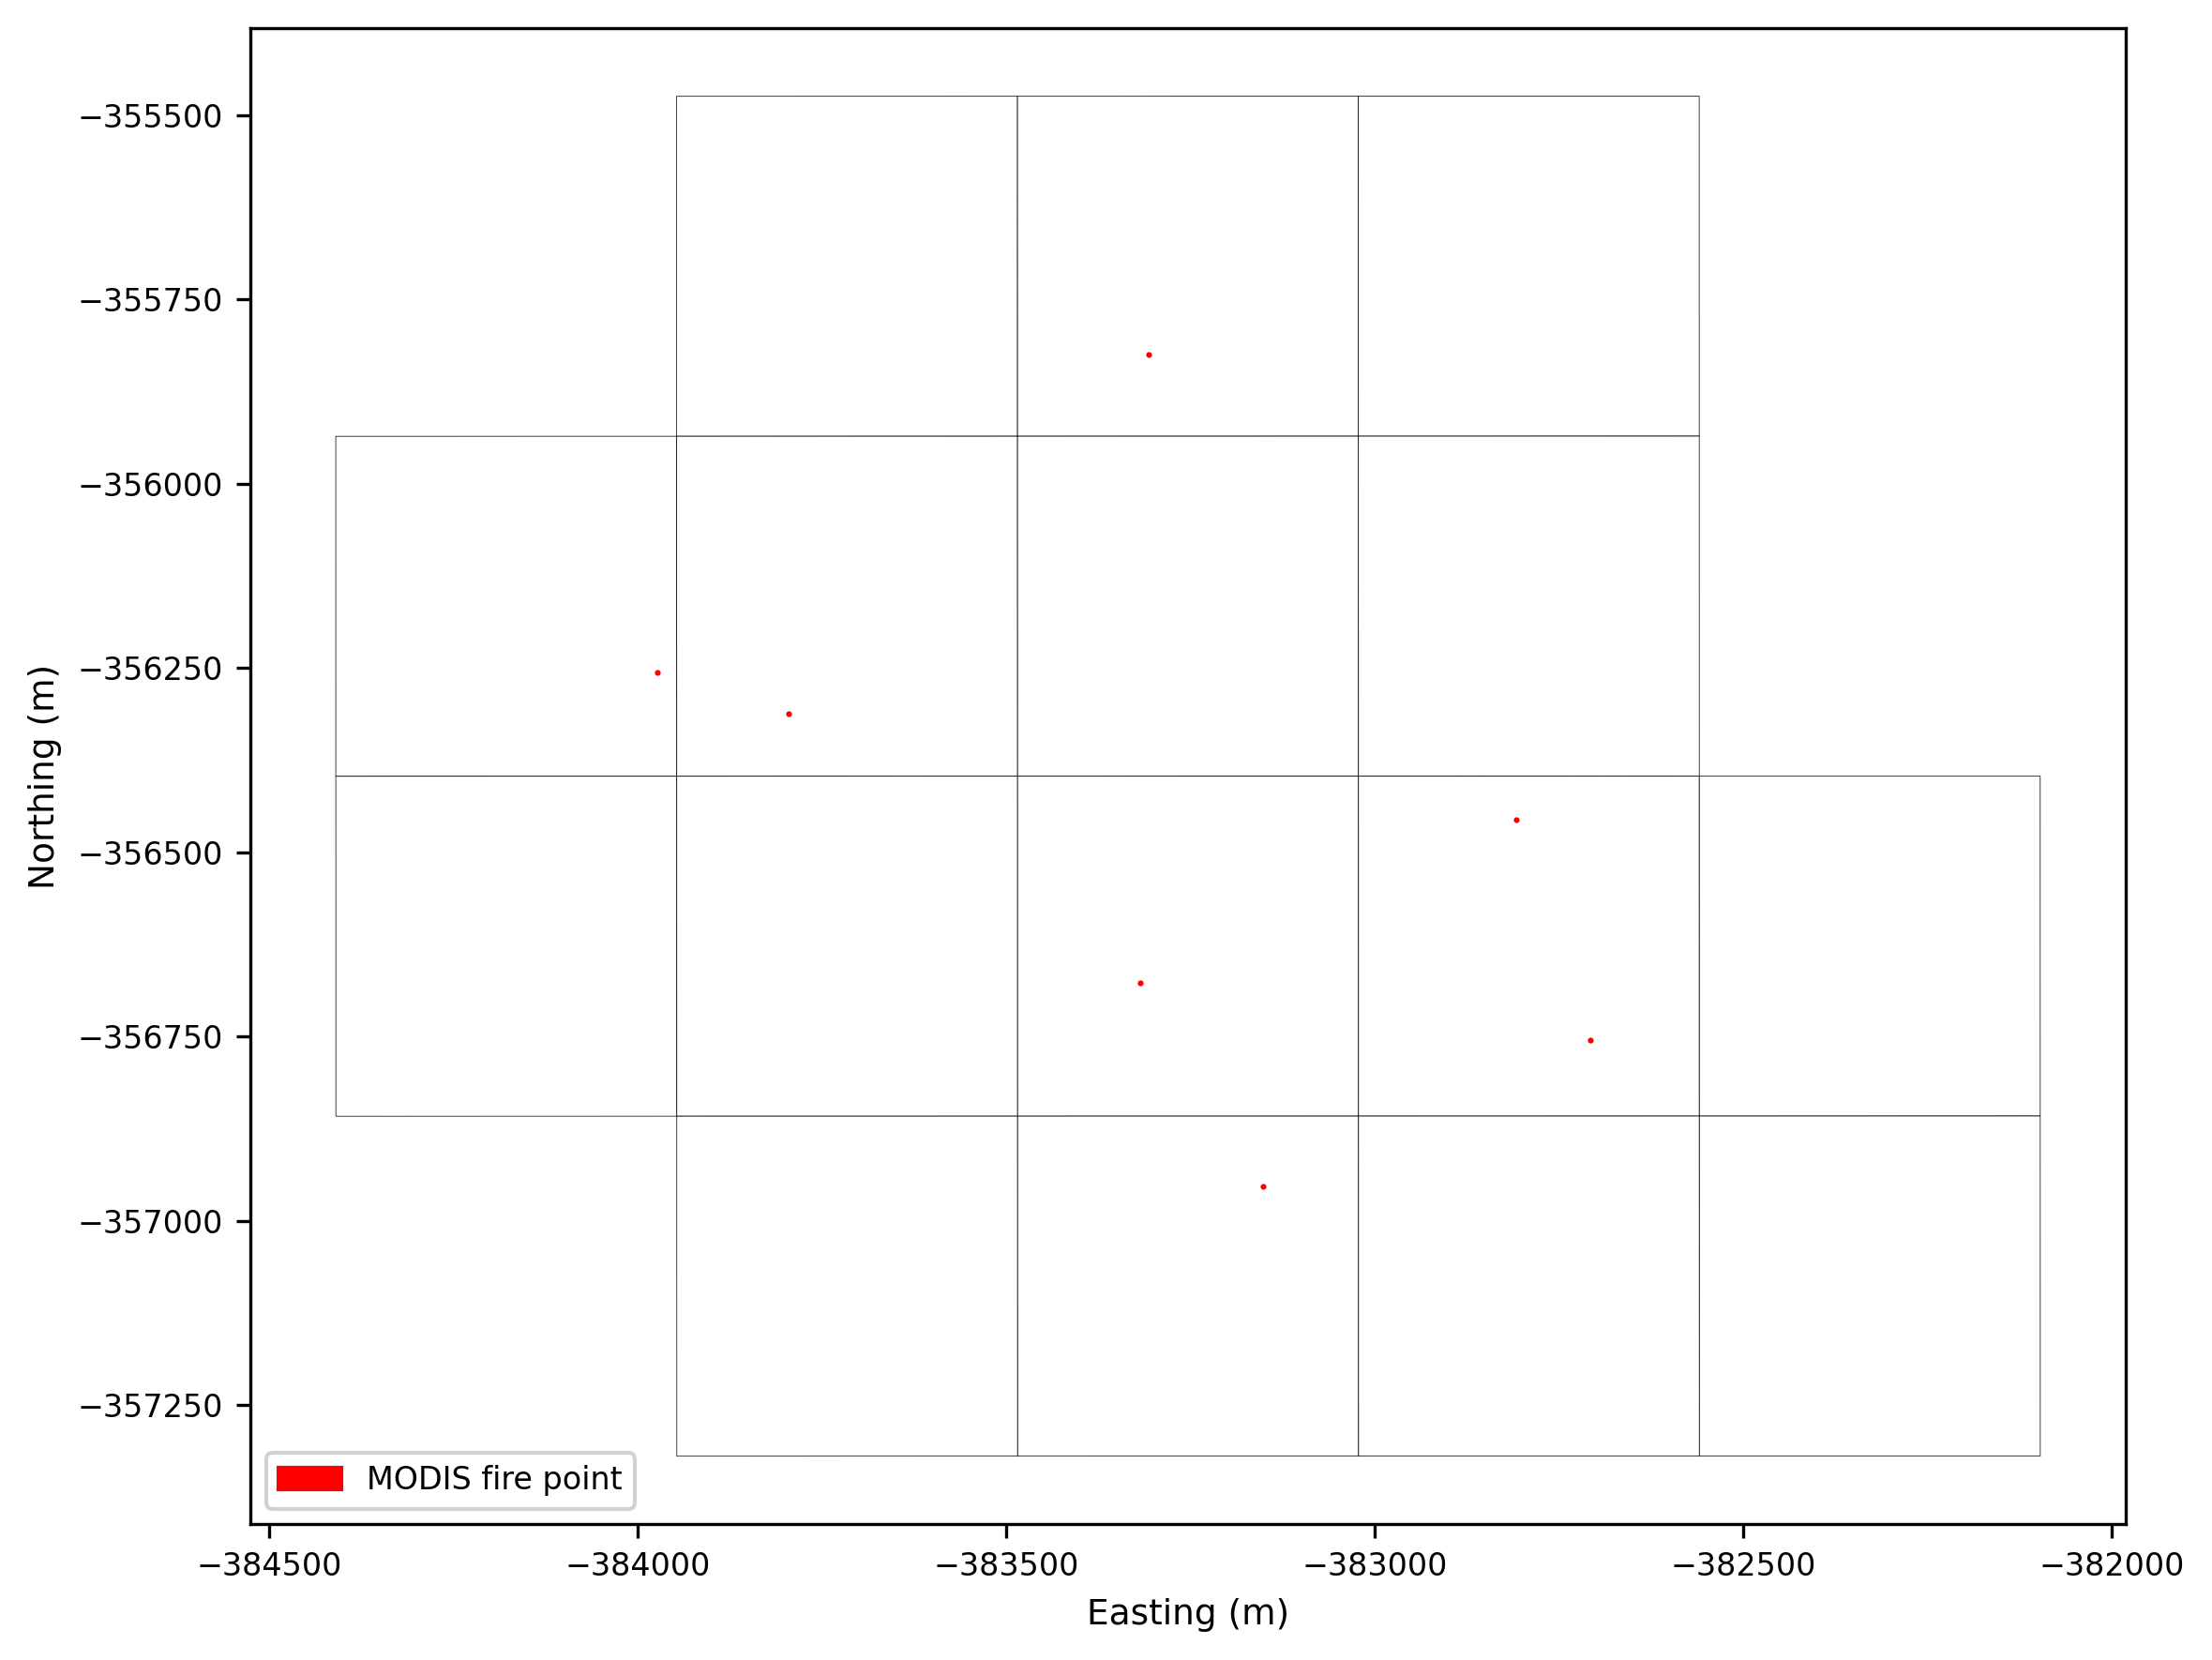

In [35]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)


# Grid cells
fire_grid.plot(
    ax=ax,
    column="af_count",      
    color="white",
    linewidth=0.2,
    edgecolor="black",
    legend=False,
    alpha=0.88,
)

# Fire points overlay
fire_point.plot(
    ax=ax,
    color="red",
    markersize=4,
    linewidth=0.5,
    edgecolor="white",
    zorder=5,
    label="MODIS fire point",
)


# Legend for points
ax.legend(
    handles=[mpatches.Patch(color="red", label="MODIS fire point")],
    fontsize=8, frameon=True, framealpha=0.9, loc="lower left"
)

# Axis tick formatting (degrees if geographic, or km if projected)
ax.set_xlabel("Easting (m)", fontsize=9)
ax.set_ylabel("Northing (m)", fontsize=9)
ax.tick_params(labelsize=8)
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("fire_point_grid.pdf", dpi=300, bbox_inches="tight")
plt.savefig("fire_point_grid.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# LULC

In [33]:
fire_grid.columns

Index(['grid_id', 'lon', 'lat', 'fire_id', 'year', 'af_count', 'area_km2',
       'buffer_m', 'date_min', 'date_max', 'af_type', 'af_ig_', 'nearest_po',
       'n_ACQ_DATE', 'n_ACQ_TIME', 'distance_t', 'nearest__1', 'nearest__2',
       'ACQ_DATE_C', 'ndvi', 'evi', 'ndvi_date', 'elevation', 'mapbiomas',
       'lulc_code', 'major_dail', 'major_da_1', 'major_da_2', 'major_lulc',
       'major_km2', 'major_pct', 'total_km2', 's_seq_3', 's_seq_5',
       'first_lulc', 'last_lulc', 'pair_end', 'month', 't2m', 'd2m', 'rh',
       'vpd', 'sst', 'wind_speed', 'dir_deg', 'gust', 'tp_hourly', 'ev_h',
       'pev_hourly', 'conv_preci', 'conv_rain_', 'sp_pa', 'mslp_pa',
       'burn_durat', 'ros_km2_da', 'geometry'],
      dtype='object')

In [40]:
# LULC Index
# From MapBiomas Indonesia Collection 4
lulc_index = {
    0: 'No Data',
    1: 'Forest',
    3: 'Forest Formation',
    5: 'Mangrove',
    9: 'Pulpwood Plantation',
    10: 'Non-Forest Natural Formation',
    13: 'Non Forest Natural Vegetation',
    18: 'Agriculture',
    21: 'Other Agriculture',
    22: 'Non Vegetated Area',
    24: 'Urban Area',
    25: 'Other Non-Vegetation',
    26: 'Water Body',
    27: 'Non Observed', # Citra Tertutup Awan
    30: 'Mining Pit',
    31: 'Aquaculture', # Tambak
    33: 'River, Lake, Ocean',
    35: 'Oil Palm',
    40: 'Rice Paddy',
    76: 'Peat Swamp Forest'
}

C:\Users\sjr6360\AppData\Local\Temp\ipykernel_3768\2991324984.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(categories))


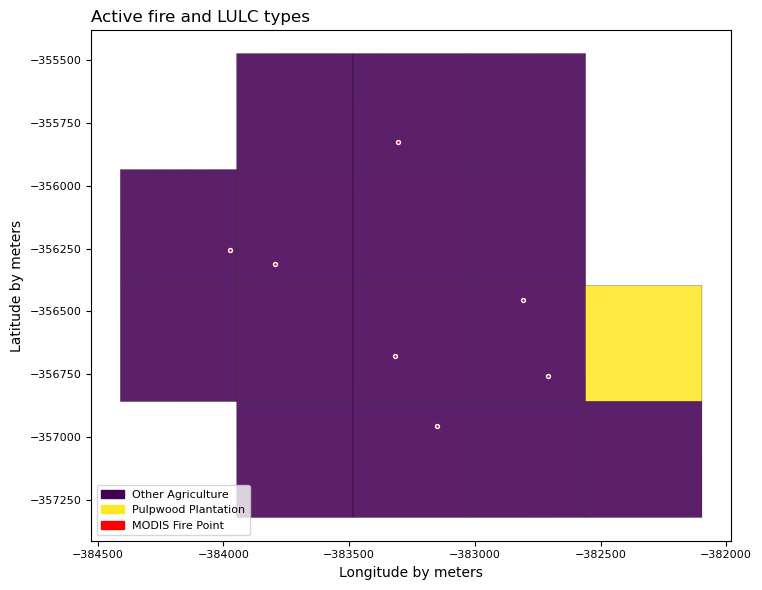

In [45]:
fig, ax = plt.subplots(figsize=(8,6))


# Convert to categorical labels
fire_grid["mapbiomas_label"] = fire_grid["mapbiomas"].map(lulc_index)
fire_grid["mapbiomas_label"] = fire_grid["mapbiomas_label"].astype("category")

# Get categories
categories = fire_grid["mapbiomas_label"].cat.categories

# Create the colormap
cmap = cm.get_cmap("viridis", len(categories))

# Plot grid
fire_grid.plot(
    ax=ax,
    column="mapbiomas_label",
    cmap=cmap,
    linewidth=0.2,
    edgecolor="black",
    legend=False,
    alpha=0.88
)

# Plot fire point
fire_point.plot(
    ax=ax,
    color="red",
    markersize=8,
    edgecolor="white",
    zorder=3
)

# Build legend
handles = [
    mpatches.Patch(color=cmap(i), label=cat)
    for i, cat in enumerate(categories)
]

handles.append(mpatches.Patch(color="red", label="MODIS Fire Point"))

ax.legend(handles=handles,
         fontsize=8,
         frameon=True,
         loc="lower left")

# Title and axis
ax.set_title("Active fire and LULC types", fontsize=12, loc="left", pad=6)
ax.set_xlabel("Longitude by meters", fontsize=10)
ax.set_ylabel("Latitude by meters", fontsize=10)
ax.tick_params(labelsize=8)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()